In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
df = pd.read_csv('/content/Customer Churn.csv')

In [ ]:
df.head()

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
0,8,0,38,0,4370,71,5,17,3,1,1,30,197.640,0
1,0,0,39,0,318,5,7,4,2,1,2,25,46.035,0
2,10,0,37,0,2453,60,359,24,3,1,1,30,1536.520,0
3,10,0,38,0,4198,66,1,35,1,1,1,15,240.020,0
4,3,0,38,0,2393,58,2,33,1,1,1,15,145.805,0


In [ ]:
df.shape

(3150, 14)

In [ ]:
df.columns

Index(['Call  Failure', 'Complains', 'Subscription  Length', 'Charge  Amount',
       'Seconds of Use', 'Frequency of use', 'Frequency of SMS',
       'Distinct Called Numbers', 'Age Group', 'Tariff Plan', 'Status', 'Age',
       'Customer Value', 'Churn'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Call  Failure            3150 non-null   int64  
 1   Complains                3150 non-null   int64  
 2   Subscription  Length     3150 non-null   int64  
 3   Charge  Amount           3150 non-null   int64  
 4   Seconds of Use           3150 non-null   int64  
 5   Frequency of use         3150 non-null   int64  
 6   Frequency of SMS         3150 non-null   int64  
 7   Distinct Called Numbers  3150 non-null   int64  
 8   Age Group                3150 non-null   int64  
 9   Tariff Plan              3150 non-null   int64  
 10  Status                   3150 non-null   int64  
 11  Age                      3150 non-null   int64  
 12  Customer Value           3150 non-null   float64
 13  Churn                    3150 non-null   int64  
dtypes: float64(1), int64(13)

In [ ]:
df.describe()

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
count,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000
mean,7.627937,0.076508,32.541905,0.942857,4472.459683,69.460635,73.174921,23.509841,2.826032,1.077778,1.248254,30.998413,470.972916,0.157143
std,7.263886,0.265851,8.573482,1.521072,4197.908687,57.413308,112.237560,17.217337,0.892555,0.267864,0.432069,8.831095,517.015433,0.363993
min,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,15.000000,0.000000,0.000000
25%,1.000000,0.000000,30.000000,0.000000,1391.250000,27.000000,6.000000,10.000000,2.000000,1.000000,1.000000,25.000000,113.801250,0.000000
50%,6.000000,0.000000,35.000000,0.000000,2990.000000,54.000000,21.000000,21.000000,3.000000,1.000000,1.000000,30.000000,228.480000,0.000000
75%,12.000000,0.000000,38.000000,1.000000,6478.250000,95.000000,87.000000,34.000000,3.000000,1.000000,1.000000,30.000000,788.388750,0.000000
max,36.000000,1.000000,47.000000,10.000000,17090.000000,255.000000,522.000000,97.000000,5.000000,2.000000,2.000000,55.000000,2165.280000,1.000000


In [ ]:
df.columns = df.columns.str.replace('  ', '_')
df.columns = df.columns.str.replace(' ', '_')

df.columns

Index(['Call_Failure', 'Complains', 'Subscription_Length', 'Charge_Amount',
       'Seconds_of_Use', 'Frequency_of_use', 'Frequency_of_SMS',
       'Distinct_Called_Numbers', 'Age_Group', 'Tariff_Plan', 'Status', 'Age',
       'Customer_Value', 'Churn'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
Call_Failure,0
Complains,0
Subscription_Length,0
Charge_Amount,0
Seconds_of_Use,0
Frequency_of_use,0
Frequency_of_SMS,0
Distinct_Called_Numbers,0
Age_Group,0
Tariff_Plan,0


In [ ]:
df.duplicated().sum()

np.int64(300)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df['Churn'].value_counts()

,count
Churn,
0,2404
1,446


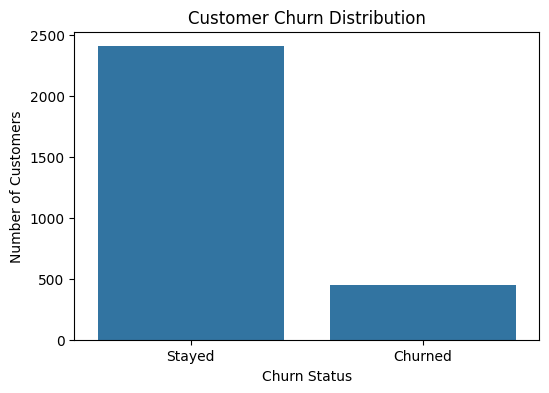

In [ ]:
## Customer Churn Distribution

plt.figure(figsize=(6,4))

sns.countplot(x='Churn', data=df)

plt.title('Customer Churn Distribution')
plt.xlabel('Churn Status')
plt.ylabel('Number of Customers')

plt.xticks([0,1], ['Stayed', 'Churned'])

plt.show()

The majority of customers remained with the telecom company, while a smaller percentage churned. This indicates an imbalanced dataset with most customers retained.

In [ ]:
(df['Churn'].value_counts(normalize=True) * 100)   #Actual Churn %

,proportion
Churn,
0,84.350877
1,15.649123


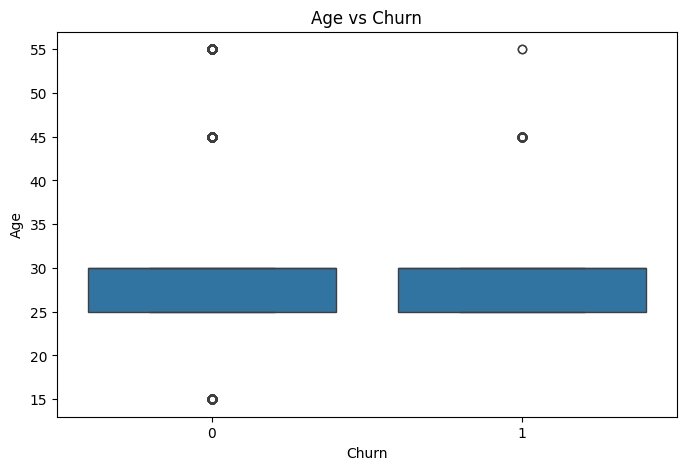

In [ ]:


plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='Age', data=df)
plt.title('Age vs Churn')
plt.show()

Age distribution appears similar for both churned and retained customers, suggesting age may not significantly influence churn behavior.

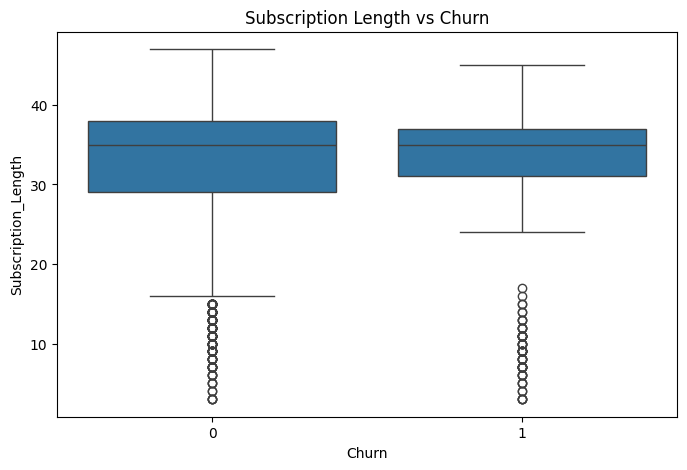

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='Subscription_Length', data=df)
plt.title('Subscription Length vs Churn')
plt.show()

Customers with shorter subscription durations show slightly higher churn tendency, indicating newer customers may be more likely to leave the service.

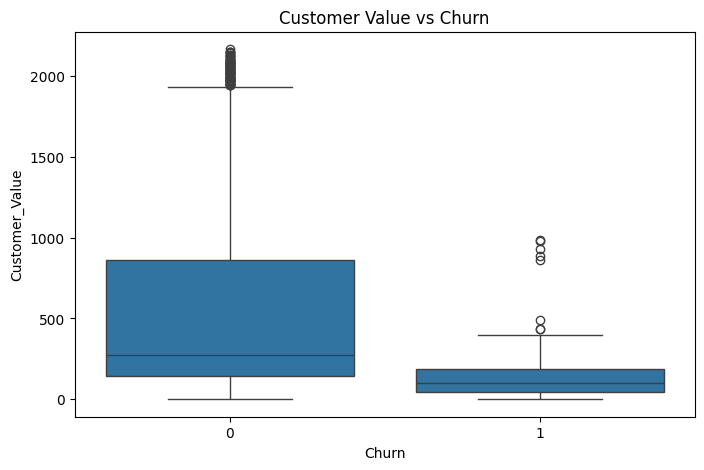

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='Customer_Value', data=df)
plt.title('Customer Value vs Churn')
plt.show()

Customers with lower customer value show significantly higher churn tendency, while high-value customers are more likely to remain with the telecom service.

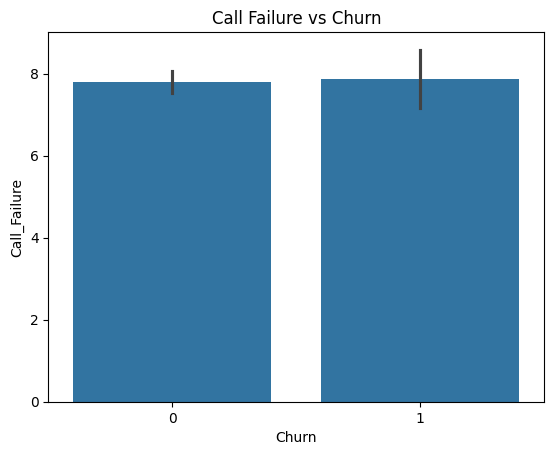

In [ ]:
sns.barplot(x='Churn', y='Call_Failure', data=df)
plt.title('Call Failure vs Churn')
plt.show()

Call failure rates appear relatively similar between churned and retained customers, suggesting this variable may have limited influence on churn behavior.

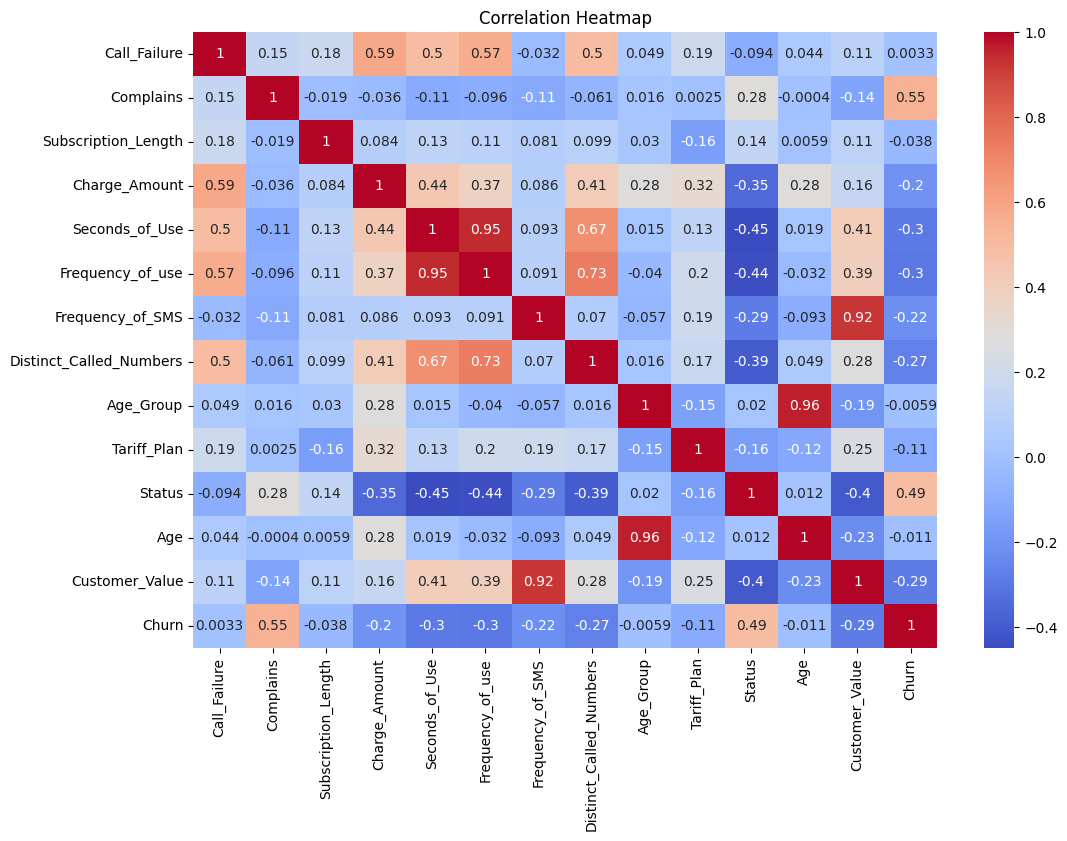

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

Customer complaints show strong positive correlation with churn, indicating dissatisfaction is a major driver of customer loss.

In [ ]:
#Seperate feature and target

X = df.drop('Churn', axis=1)
y = df['Churn']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
accuracy_score(y_test, y_pred)

0.8929824561403509

In [ ]:
print(confusion_matrix(y_test, y_pred))

[[467  12]
 [ 49  42]]


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.97      0.94       479
           1       0.78      0.46      0.58        91

    accuracy                           0.89       570
   macro avg       0.84      0.72      0.76       570
weighted avg       0.88      0.89      0.88       570



In [ ]:
rf = RandomForestClassifier()

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

accuracy_score(y_test, rf_pred)

0.9596491228070175

In [ ]:
# Key Business Insights

#- Customers with lower customer value show higher churn probability.
#- Customer complaints strongly relate to churn behavior.
#- Lower service usage is associated with increased churn risk.
#- Shorter subscription periods show slightly higher churn tendency.
#- High-value retained customers contribute significantly to business stability.

In [ ]:
# Business Recommendations

#- Improve customer support for users with complaints.
#- Create loyalty programs for low-engagement customers.
#- Offer retention incentives for newer subscribers.
#- Monitor customers with declining usage patterns.

In [ ]:
df.to_csv('cleaned_customer_churn.csv', index=False)